# Fig. 1 — phenomenology of HDX–MS envelopes

Four conformational scenarios (uncoupled, concerted switching, conformational heterogeneity, local and global unfolding) at five labeling times, with a back-exchange correction applied at the pattern level.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
import hdx_backexchange as BX
from hdx_env import (UncoupledResidues, ConcertedSwitching,
                     MetastableBasins, averagine_composition,
                     natural_envelope, mass_envelope, COLORS)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
# ---------------------------------------------------------------------------
# Common peptide parameters — identical to mass_envelope_phenomenology.ipynb
# k_int = 1 throughout; k_eff ≈ 0.2 across scenarios.
# ---------------------------------------------------------------------------
N       = 8
P       = tuple(range(N))
k_int   = np.ones(N)
t_snaps = np.array([0.0, 10.0, 60.0, 100.0, 1000.0])

kop, kcl = 0.01, 0.1

# Back-exchange retention (uniform across all residues)
beta = np.full(N, 0.92)
print(f'beta_i = {beta[0]:.2f} (uniform)    back-exchange fraction = {1 - beta[0]:.2f}')

beta_i = 0.92 (uniform)    back-exchange fraction = 0.08


In [3]:
# ---------------------------------------------------------------------------
# Four conformational scenarios — same as the phenomenology figure
# ---------------------------------------------------------------------------
model_a = UncoupledResidues(np.full(N, kop), np.full(N, kcl), k_int)
model_b = ConcertedSwitching(kop, kcl, k_int)

pi_basins_c = np.stack([
    np.full(N, 0.01),
    np.full(N, 1.0 ),
])
p0_basins_c = np.array([0.70, 0.30])
model_c = MetastableBasins(pi_basins_c, k_int, p0_basin=p0_basins_c)

W_d = np.array(([-kop, +kop],
                [+kcl, -kcl]))
model_d = MetastableBasins(pi_basins_c, k_int, W_basin=W_d)

scenarios = [
    ('a', "uncoupled residues\n``EX2''",                       model_a, COLORS['uncoupled']),
    ('b', "concerted switching\n``EX1''",                      model_b, COLORS['concerted']),
    ('c', "conformational heterogeneity\n``mixed species''",   model_c, COLORS['basins']),
    ('d', "local and global unfolding\n``EX1 and EX2''",       model_d, COLORS['other1']),
]

# ---------------------------------------------------------------------------
# Uptake distributions (ideal and back-exchange-corrected) per scenario
# ---------------------------------------------------------------------------
envs_no_bx = []
envs_bx    = []

peptide_mass = 110.0 * N
nat_env      = natural_envelope(averagine_composition(peptide_mass), n_peaks=15)
L_env        = N + len(nat_env)

for label, title, model, col in scenarios:
    prob_bx, prob_no_bx, _ = BX.envelope_with_backexchange(model, P, t_snaps, beta)
    envs_no_bx.append(mass_envelope(prob_no_bx, nat_env, n_peaks=L_env))
    envs_bx   .append(mass_envelope(prob_bx,    nat_env, n_peaks=L_env))

## Figure

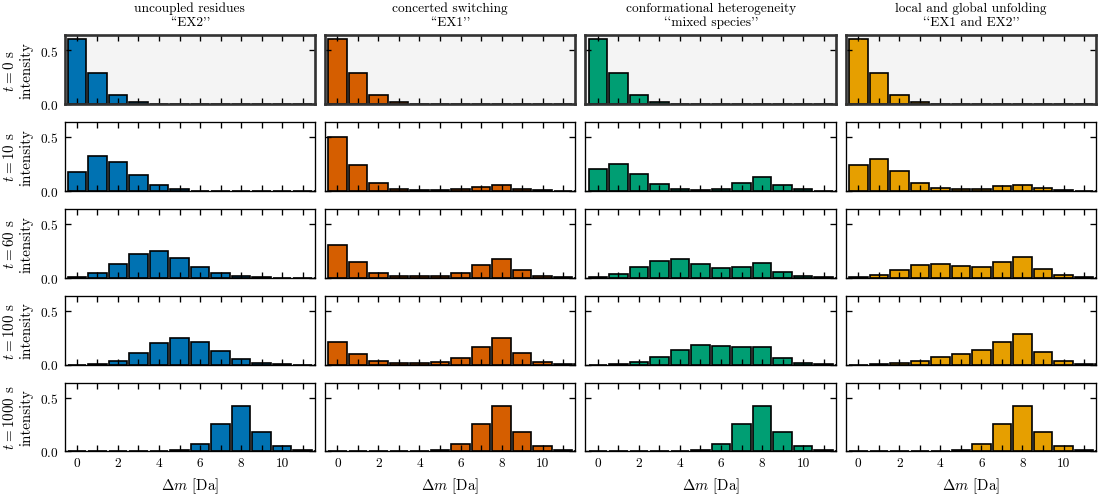

In [4]:
fig, axes = plt.subplots(len(t_snaps), len(scenarios),
                         figsize=(9.2, 4.2),
                         sharex=True, sharey=True,
                         constrained_layout=True)
offs = np.arange(L_env)

x_ticks      = np.arange(0, N + 4, 1)
x_ticklabels = [tk if tk % 2 == 0 else '' for tk in x_ticks]

for ri, ((label, title, model, col), env_no_bx, env_bx) in enumerate(
        zip(scenarios, envs_no_bx, envs_bx)):
    for ti, tsnap in enumerate(t_snaps):
        ax = axes[ti, ri]

        # background: ideal envelope (no back exchange)
        #ax.bar(offs[:env_no_bx.shape[1]], env_no_bx[ti], width=0.9,
        #       color=col, alpha=0.25, edgecolor='none',
        #       label='ideal' if (ti == 0 and ri == 0) else None)
        # foreground: back-exchange-corrected envelope
        ax.bar(offs[:env_bx.shape[1]], env_bx[ti], width=0.9,
               color=col, edgecolor='black', lw=1,
               label=r'back exchange ($\beta=0.92$)' if (ti == 0 and ri == 0) else None)

        if ti == 0:
            ax.set_title(title, fontsize=8)
            ax.text(0.03, 0.94, label, transform=ax.transAxes,
                    fontsize=9, fontweight='bold', color=col,
                    va='top', ha='left')
            for sp in ax.spines.values():
                sp.set_linewidth(1.6)
                sp.set_color('0.2')
            ax.set_facecolor('#f4f4f4')
        if ri == 0:
            ax.set_ylabel(rf'$t={tsnap:g}$ s' + '\n' + r'intensity')
        if ti == len(t_snaps) - 1:
            ax.set_xlabel(r'$\Delta m$ [Da]')
        ax.set_xlim(-0.6, N + 3.6)
        ax.set_xticks(x_ticks, labels=x_ticklabels)

# Single global legend in the very first panel
#axes[0, 0].legend(loc='upper right', fontsize=6,
#                  handlelength=1.0, frameon=False,
#                  borderpad=0.2, labelspacing=0.2)

fig.savefig(os.path.join(PLOTS_DIR,
            'fig_mass_envelope_phenomenology_backexchange.pdf'))
plt.show()

## Cross-check

In [5]:
kvals = np.arange(N + 1)
for (label, title, model, col) in scenarios:
    prob_bx, prob_no_bx, _ = BX.envelope_with_backexchange(
        model, P, t_snaps, beta)
    m_bx    = (prob_bx    * kvals).sum(axis=1)
    m_no_bx = (prob_no_bx * kvals).sum(axis=1)
    ratio = np.divide(m_bx, m_no_bx,
                       out=np.full_like(m_bx, np.nan),
                       where=m_no_bx > 0)
    print(f'{label}  centroid ratio (BX/ideal): {ratio.round(4)}  → expected {beta[0]:.2f}')

a  centroid ratio (BX/ideal): [ nan 0.92 0.92 0.92 0.92]  → expected 0.92
b  centroid ratio (BX/ideal): [4.1389 0.92   0.92   0.92   0.92  ]  → expected 0.92
c  centroid ratio (BX/ideal): [ nan 0.92 0.92 0.92 0.92]  → expected 0.92
d  centroid ratio (BX/ideal): [0.2847 0.92   0.92   0.92   0.92  ]  → expected 0.92
